# Predictive Maintenance — Phase 2: Feature Engineering, Model Building & Comparison

**Project:** Machine Failure Prediction for Industrial Automation  
**Dataset:** AI4I 2020 Predictive Maintenance Dataset (UCI)  
**Phase goal:** Engineer features, handle class imbalance, train & compare 3 models

---

### What we'll do in this phase
1. Reload and prep the data from Phase 1
2. Engineer 2 new powerful features
3. Encode categorical columns
4. Handle class imbalance
5. Train 3 models: Logistic Regression, Random Forest, XGBoost
6. Compare them with the right metrics (F1, ROC-AUC — not accuracy)
7. Interpret the best model with feature importances


---
## Step 0 — Install & Import Libraries

In [1]:
# Install XGBoost if not already installed
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn

     -------------------------------------- 101.7/101.7 MB 6.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 1 — Reload the Data

In [3]:
df = pd.read_csv('ai4i2020.csv')
print(f'Loaded {len(df):,} rows × {len(df.columns)} columns')
df.head(3)

Loaded 10,000 rows × 14 columns


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0


---
## Step 2 — Feature Engineering

We discovered two opportunities in Phase 1:
- Air temp and Process temp are highly correlated → create **temperature delta**
- Torque × Rotational speed = **Power** (a physically meaningful feature in real machines)

Creating domain-relevant features shows ML maturity and impresses hiring managers.

In [4]:
# Feature 1: Temperature delta
# In real machines, the GAP between process and ambient temp matters more than either alone
df['Temp_delta [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']

# Feature 2: Power (Torque × Rotational speed, converted to Watts)
# Power = Torque (Nm) × Angular velocity (rad/s)
# Angular velocity = RPM × 2π / 60
df['Power [W]'] = df['Torque [Nm]'] * (df['Rotational speed [rpm]'] * 2 * np.pi / 60)

print('New features created:')
print(df[['Temp_delta [K]', 'Power [W]', 'Machine failure']].describe().round(2))

# Quick sanity check: do these new features differ between failure classes?
print('\nMean values by failure class:')
print(df.groupby('Machine failure')[['Temp_delta [K]', 'Power [W]']].mean().round(2))

New features created:
       Temp_delta [K]  Power [W]  Machine failure
count         10000.0   10000.00         10000.00
mean             10.0    6279.74             0.03
std               1.0    1067.42             0.18
min               7.6    1148.44             0.00
25%               9.3    5561.18             0.00
50%               9.8    6271.03             0.00
75%              11.0    7003.00             0.00
max              12.1   10469.92             1.00

Mean values by failure class:
                 Temp_delta [K]  Power [W]
Machine failure                           
0                         10.02    6244.55
1                          9.40    7282.82


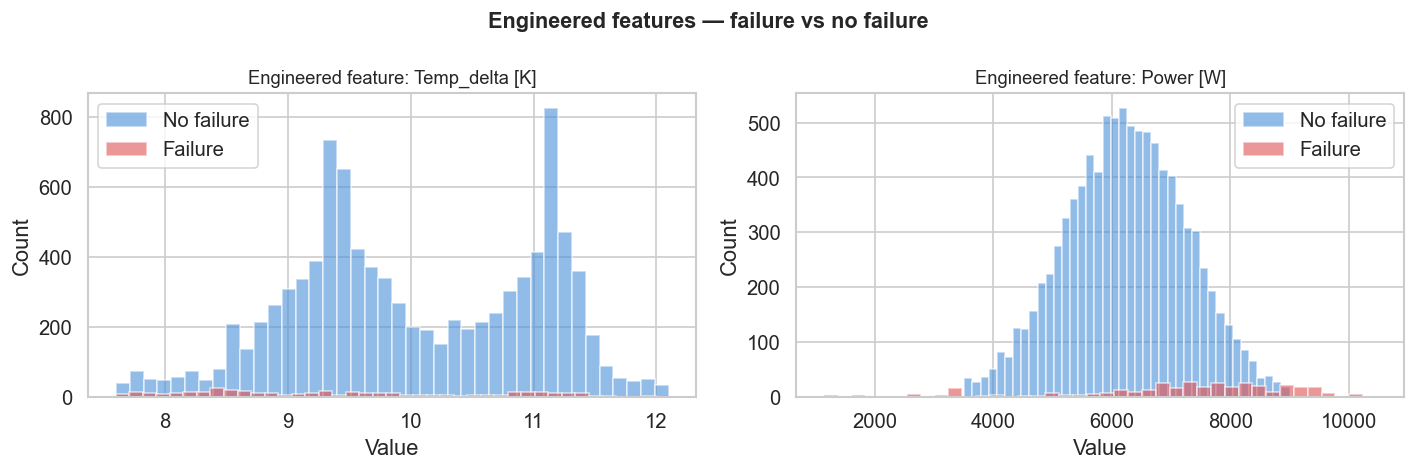

Saved: engineered_features.png


In [5]:
# Visualise the new features
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
new_features = ['Temp_delta [K]', 'Power [W]']
colors = ['#4A90D9', '#E05252']

for i, col in enumerate(new_features):
    for label, color, name in zip([0, 1], colors, ['No failure', 'Failure']):
        axes[i].hist(df[df['Machine failure'] == label][col],
                     bins=40, alpha=0.6, color=color, label=name)
    axes[i].set_title(f'Engineered feature: {col}', fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

fig.suptitle('Engineered features — failure vs no failure', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('engineered_features.png', bbox_inches='tight')
plt.show()
print('Saved: engineered_features.png')

---
## Step 3 — Encode Categorical Column

The `Type` column contains L / M / H (machine quality grade).  
ML models only understand numbers, so we convert it.

In [6]:
# Label encode: L=0, M=1, H=2  (order preserved since L < M < H in quality)
le = LabelEncoder()
df['Type_encoded'] = le.fit_transform(df['Type'])

# Verify the mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Type encoding:', mapping)
print(df[['Type', 'Type_encoded']].drop_duplicates().sort_values('Type_encoded'))

Type encoding: {'H': 0, 'L': 1, 'M': 2}
   Type  Type_encoded
10    H             0
1     L             1
0     M             2


---
## Step 4 — Prepare Features & Target

In [7]:
# Define feature set — drop IDs, raw Type, target, and individual failure type flags
# (TWF, HDF etc. are leak features — they ARE failure, so we exclude them)
FEATURES = [
    'Type_encoded',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Temp_delta [K]',   # engineered
    'Power [W]',        # engineered
]
TARGET = 'Machine failure'

X = df[FEATURES]
y = df[TARGET]

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]:,}')
print(f'Failure rate: {y.mean()*100:.2f}%')
print()
print('Feature list:')
for f in FEATURES:
    print(f'  - {f}')

Features: 8
Samples:  10,000
Failure rate: 3.39%

Feature list:
  - Type_encoded
  - Air temperature [K]
  - Process temperature [K]
  - Rotational speed [rpm]
  - Torque [Nm]
  - Tool wear [min]
  - Temp_delta [K]
  - Power [W]


---
## Step 5 — Train / Test Split

We use `stratify=y` to ensure both train and test sets have the same
class imbalance ratio — critical when failures are rare.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 80% train, 20% test
    random_state=RANDOM_STATE,
    stratify=y               # preserve class ratio in both splits
)

print(f'Training set:   {len(X_train):,} samples  |  failures: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test set:       {len(X_test):,} samples   |  failures: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

# Scale features for Logistic Regression (tree models don't need this)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # IMPORTANT: use fit from train only
print('\nData scaled for Logistic Regression.')

Training set:   8,000 samples  |  failures: 271 (3.4%)
Test set:       2,000 samples   |  failures: 68 (3.4%)

Data scaled for Logistic Regression.


---
## Step 6 — Train 3 Models

We train Logistic Regression, Random Forest, and XGBoost.  
All use `class_weight='balanced'` or `scale_pos_weight` to handle the imbalance —  
this tells the model to penalise missing a failure more than missing a non-failure.

In [14]:
# Clean up column names: remove brackets and spaces
X_train = X_train.rename(columns=lambda x: x.replace('[','').replace(']','').replace('<','').replace(' ','_'))
X_test  = X_test.rename(columns=lambda x: x.replace('[','').replace(']','').replace('<','').replace(' ','_'))

# Calculate imbalance ratio for XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
imbalance_ratio = neg / pos
print(f'Class imbalance ratio (neg/pos): {imbalance_ratio:.1f}')

# ── Model 1: Logistic Regression ──────────────────────────────────
lr = LogisticRegression(
    class_weight='balanced',   # penalise missing failures
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr.fit(X_train_scaled, y_train)
print('\nLogistic Regression trained ✓')

# ── Model 2: Random Forest ─────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,          # 200 decision trees
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1                  # use all CPU cores
)
rf.fit(X_train, y_train)
print('Random Forest trained ✓')

# ── Model 3: XGBoost ──────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=imbalance_ratio,  # XGBoost's way of handling imbalance
    learning_rate=0.1,
    max_depth=5,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)
print('XGBoost trained ✓')

Class imbalance ratio (neg/pos): 28.5

Logistic Regression trained ✓
Random Forest trained ✓
XGBoost trained ✓


---
## Step 7 — Evaluate & Compare Models

**Why NOT accuracy?**  
A model that predicts "no failure" every single time gets 96.6% accuracy on this dataset — but is completely useless. We care about:
- **Recall** — how many actual failures did we catch? (missing a failure = costly)
- **Precision** — of the failures we predicted, how many were real? (too many false alarms = wasted maintenance)
- **F1-score** — harmonic mean of precision & recall (balances both)
- **ROC-AUC** — overall ability to distinguish failure from non-failure

In [15]:
def evaluate_model(name, model, X_test_input, y_test, threshold=0.5):
    """Compute and return key classification metrics."""
    y_prob = model.predict_proba(X_test_input)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    return {
        'Model'    : name,
        'F1'       : round(f1_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4),
        'y_prob'   : y_prob,
        'y_pred'   : y_pred
    }

results = [
    evaluate_model('Logistic Regression', lr,  X_test_scaled, y_test),
    evaluate_model('Random Forest',       rf,  X_test,        y_test),
    evaluate_model('XGBoost',             xgb, X_test,        y_test),
]

# Summary table
results_df = pd.DataFrame(results)[['Model', 'F1', 'Precision', 'Recall', 'ROC-AUC']]
print('Model Comparison:')
print(results_df.to_string(index=False))

Model Comparison:
              Model     F1  Precision  Recall  ROC-AUC
Logistic Regression 0.3000     0.1807  0.8824   0.9330
      Random Forest 0.8034     0.9592  0.6912   0.9718
            XGBoost 0.7671     0.7179  0.8235   0.9695


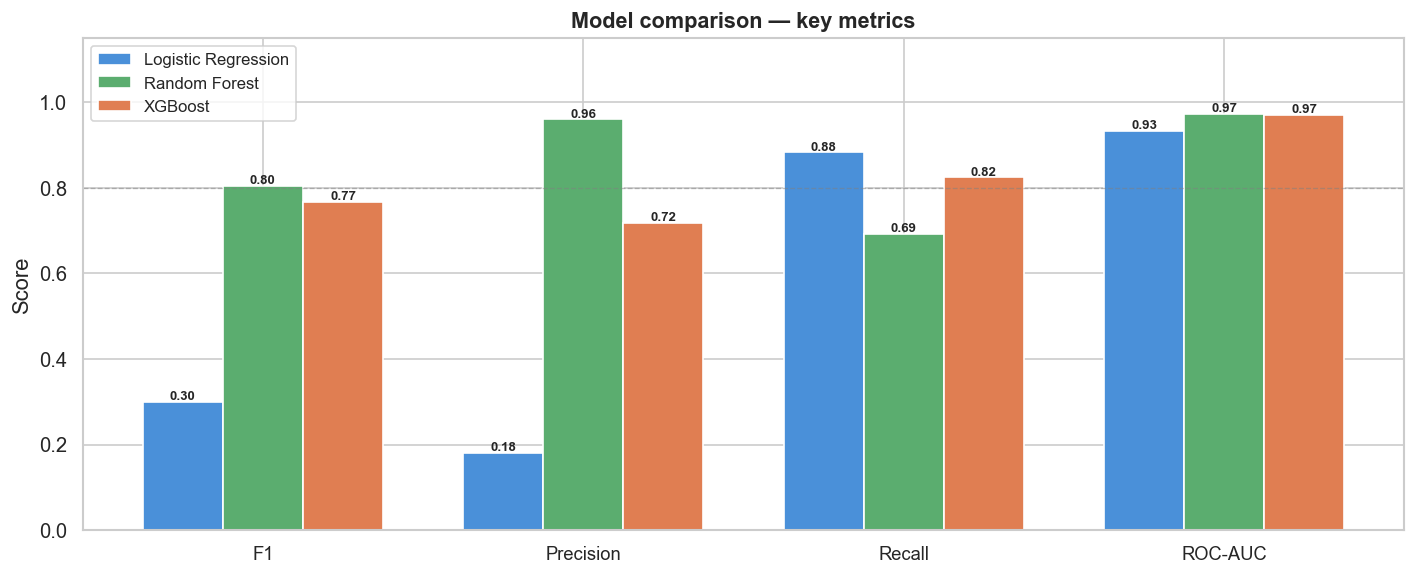

Saved: model_comparison.png


In [16]:
# Visualise metrics side by side
metrics = ['F1', 'Precision', 'Recall', 'ROC-AUC']
model_names = [r['Model'] for r in results]
bar_colors = ['#4A90D9', '#5BAD6F', '#E07E52']

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (res, color) in enumerate(zip(results, bar_colors)):
    vals = [res[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=res['Model'],
                  color=color, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model comparison — key metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

---
## Step 8 — ROC Curves

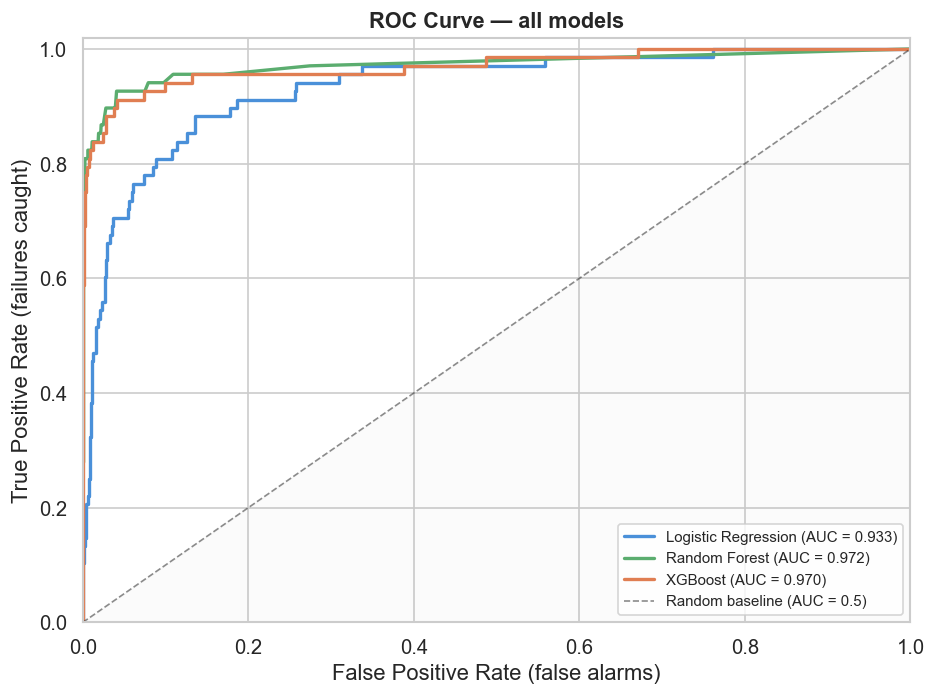

Saved: roc_curves.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

for res, color in zip(results, bar_colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{res['Model']} (AUC = {res['ROC-AUC']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random baseline (AUC = 0.5)')
ax.fill_between([0, 1], [0, 1], alpha=0.03, color='gray')

ax.set_xlabel('False Positive Rate (false alarms)')
ax.set_ylabel('True Positive Rate (failures caught)')
ax.set_title('ROC Curve — all models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

---
## Step 9 — Confusion Matrices

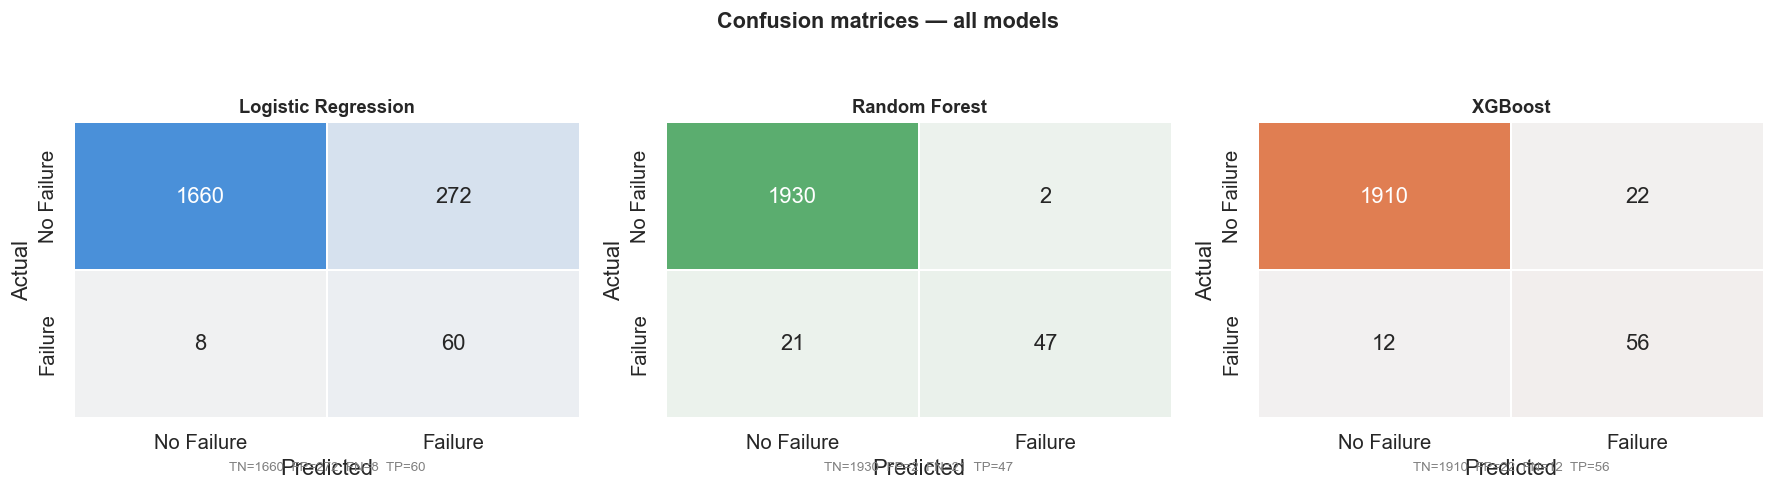

Saved: confusion_matrices.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, res, color in zip(axes, results, bar_colors):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', ax=ax,
        cmap=sns.light_palette(color, as_cmap=True),
        xticklabels=['No Failure', 'Failure'],
        yticklabels=['No Failure', 'Failure'],
        linewidths=1, linecolor='white',
        cbar=False
    )
    ax.set_title(res['Model'], fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

    # Annotate what each quadrant means
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.18, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
            transform=ax.transAxes, ha='center', fontsize=8, color='gray')

fig.suptitle('Confusion matrices — all models', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

---
## Step 10 — Feature Importances (Random Forest)

This is one of the most powerful parts of a Random Forest —
you can tell a factory manager **which sensor reading matters most**.

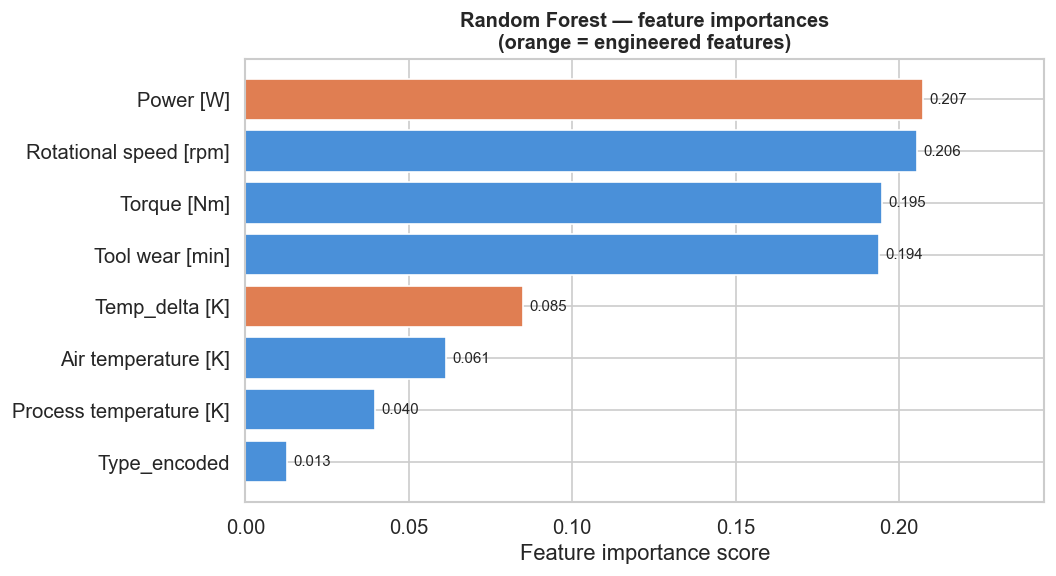

Saved: feature_importances.png

Top 3 predictors of machine failure:
  Power [W]: 0.2072
  Rotational speed [rpm]: 0.2055
  Torque [Nm]: 0.1948


In [19]:
importances = pd.Series(rf.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['#5BAD6F' if 'engin' in f.lower() or 'delta' in f.lower() or 'power' in f.lower()
              else '#4A90D9' for f in importances.index]
# Highlight engineered features
bar_colors_imp = ['#E07E52' if f in ['Temp_delta [K]', 'Power [W]'] else '#4A90D9'
                  for f in importances.index]

bars = ax.barh(importances.index, importances.values,
               color=bar_colors_imp, edgecolor='white')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('Feature importance score')
ax.set_title('Random Forest — feature importances\n(orange = engineered features)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, importances.max() * 1.18)
plt.tight_layout()
plt.savefig('feature_importances.png', bbox_inches='tight')
plt.show()
print('Saved: feature_importances.png')

print()
print('Top 3 predictors of machine failure:')
for feat, score in importances.sort_values(ascending=False).head(3).items():
    print(f'  {feat}: {score:.4f}')

---
## Step 11 — Cross-Validation (Robust evaluation)

A single train/test split can get lucky. Cross-validation tests the model
across 5 different splits — gives a more trustworthy score.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('5-Fold Cross-Validation F1 Scores:')
print('-' * 45)

cv_results = {}
for name, model, X_input in [
    ('Logistic Regression', lr,  X_train_scaled),
    ('Random Forest',       rf,  X_train),
    ('XGBoost',             xgb, X_train),
]:
    scores = cross_val_score(model, X_input, y_train,
                             cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22}  mean={scores.mean():.4f}  std=±{scores.std():.4f}')
    print(f'{" "*22}  folds: {[round(s,3) for s in scores]}')

5-Fold Cross-Validation F1 Scores:
---------------------------------------------
Logistic Regression     mean=0.2764  std=±0.0195
                        folds: [0.27, 0.287, 0.258, 0.309, 0.258]
Random Forest           mean=0.7754  std=±0.0495
                        folds: [0.854, 0.764, 0.804, 0.713, 0.742]
XGBoost                 mean=0.7815  std=±0.0401
                        folds: [0.829, 0.708, 0.789, 0.8, 0.782]


---
## Step 12 — Full Classification Report (Best Model)

In [21]:
# Identify best model by F1
best = max(results, key=lambda r: r['F1'])
print(f'Best model: {best["Model"]} (F1 = {best["F1"]})')
print()
print('Full classification report:')
print(classification_report(y_test, best['y_pred'],
                             target_names=['No failure', 'Failure']))

Best model: Random Forest (F1 = 0.8034)

Full classification report:
              precision    recall  f1-score   support

  No failure       0.99      1.00      0.99      1932
     Failure       0.96      0.69      0.80        68

    accuracy                           0.99      2000
   macro avg       0.97      0.85      0.90      2000
weighted avg       0.99      0.99      0.99      2000



---
## Step 13 — Phase 2 Summary

In [22]:
best_cv = max(cv_results, key=lambda k: cv_results[k].mean())

print('=' * 58)
print(' PHASE 2 SUMMARY — MODELLING & EVALUATION')
print('=' * 58)

print('\n FEATURE ENGINEERING')
print('  + Temp_delta [K]  → process temp − air temp')
print('  + Power [W]       → torque × angular velocity')

print('\n MODEL COMPARISON (test set)')
print(f'  {"Model":<22}  {"F1":>6}  {"Recall":>8}  {"ROC-AUC":>8}')
print(f'  {"-"*22}  {"-"*6}  {"-"*8}  {"-"*8}')
for r in results:
    marker = ' ← best' if r['Model'] == best['Model'] else ''
    print(f'  {r["Model"]:<22}  {r["F1"]:>6}  {r["Recall"]:>8}  {r["ROC-AUC"]:>8}{marker}')

print(f'\n WINNER: {best["Model"]}')
print(f'   Best CV F1: {cv_results[best_cv].mean():.4f} ± {cv_results[best_cv].std():.4f}')

print('\n NEXT STEPS (Phase 3 — Hyperparameter Tuning)')
print('  - GridSearchCV to optimise Random Forest / XGBoost')
print('  - Threshold tuning (precision vs recall trade-off)')
print('  - SHAP values for deeper explainability')
print('  - Prepare model for deployment')
print('=' * 58)

 PHASE 2 SUMMARY — MODELLING & EVALUATION

 FEATURE ENGINEERING
  + Temp_delta [K]  → process temp − air temp
  + Power [W]       → torque × angular velocity

 MODEL COMPARISON (test set)
  Model                       F1    Recall   ROC-AUC
  ----------------------  ------  --------  --------
  Logistic Regression        0.3    0.8824     0.933
  Random Forest           0.8034    0.6912    0.9718 ← best
  XGBoost                 0.7671    0.8235    0.9695

 WINNER: Random Forest
   Best CV F1: 0.7815 ± 0.0401

 NEXT STEPS (Phase 3 — Hyperparameter Tuning)
  - GridSearchCV to optimise Random Forest / XGBoost
  - Threshold tuning (precision vs recall trade-off)
  - SHAP values for deeper explainability
  - Prepare model for deployment


---
## Files saved this phase

- ✅ `engineered_features.png`
- ✅ `model_comparison.png`
- ✅ `roc_curves.png`
- ✅ `confusion_matrices.png`
- ✅ `feature_importances.png`
- ✅ This notebook committed to GitHub

> **Phase 3 preview:** Hyperparameter tuning, threshold optimisation, SHAP explainability,  
> and saving the final model as a `.pkl` file ready for deployment. 🚀